In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Unsupervised Learning Part 2 -- Clustering

Clustering is the task of gathering samples into groups of similar
samples according to some predefined similarity or distance (dissimilarity)
measure, such as the Euclidean distance.
In this section we will explore a basic clustering task on some synthetic and real-world datasets.

Here are some common applications of clustering algorithms:

- Compression for data reduction
- Summarizing data as a reprocessing step for recommender systems
- Similarly:
   - grouping related web news (e.g. Google News) and web search results
   - grouping related stock quotes for investment portfolio management
   - building customer profiles for market analysis
- Building a code book of prototype samples for unsupervised feature extraction

Let's start by creating a simple, 2-dimensional, synthetic dataset:

In [4]:
from sklearn.datasets import make_blobs
X, y = make_blobs(random_state=42, n_samples=300, centers=3, cluster_std=0.60)
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (300, 2)
y shape: (300,)


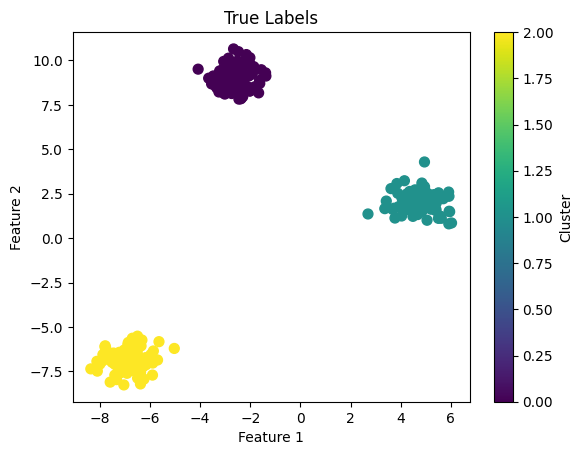

In [5]:
# Scatter plot of the data with true labels
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
plt.title('True Labels')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster')
plt.show()

In the scatter plot above, we can see three separate groups of data points and we would like to recover them using clustering -- think of "discovering" the class labels that we already take for granted in a classification task.

Even if the groups are obvious in the data, it is hard to find them when the data lives in a high-dimensional space, which we can't visualize in a single histogram or scatterplot.

Now we will use one of the simplest clustering algorithms, K-means.
This is an iterative algorithm which searches for three cluster
centers such that the distance from each point to its cluster is
minimized. The standard implementation of K-means uses the Euclidean distance, which is why we want to make sure that all our variables are measured on the same scale if we are working with real-world datastets. In the previous notebook, we talked about one technique to achieve this, namely, standardization.

**Question:** what would you expect the output to look like?

In [6]:
from sklearn.cluster import KMeans

# Fit KMeans with 3 clusters
km = KMeans(n_clusters=3, random_state=42)
km.fit(X)
print('KMeans fitted successfully!')

KMeans fitted successfully!


We can get the cluster labels either by calling fit and then accessing the
``labels_`` attribute of the K means estimator, or by calling ``fit_predict``.
Either way, the result contains the ID of the cluster that each point is assigned to.

In [7]:
# Get cluster labels using labels_ attribute
labels = km.labels_
print('Cluster labels (first 10):', labels[:10])
print('Unique labels:', set(labels))

Cluster labels (first 10): [1 1 0 2 1 2 0 2 0 0]
Unique labels: {np.int32(0), np.int32(1), np.int32(2)}


In [8]:
# Alternatively, using fit_predict
labels_pred = km.fit_predict(X)
print('Labels from fit_predict (first 10):', labels_pred[:10])

Labels from fit_predict (first 10): [1 1 0 2 1 2 0 2 0 0]


In [9]:
# Print the cluster centers
print('Cluster centers:')
print(km.cluster_centers_)

Cluster centers:
[[-2.58361866  9.03185632]
 [-6.88217395 -6.94243433]
 [ 4.70421356  1.99562444]]


Let's visualize the assignments that have been found

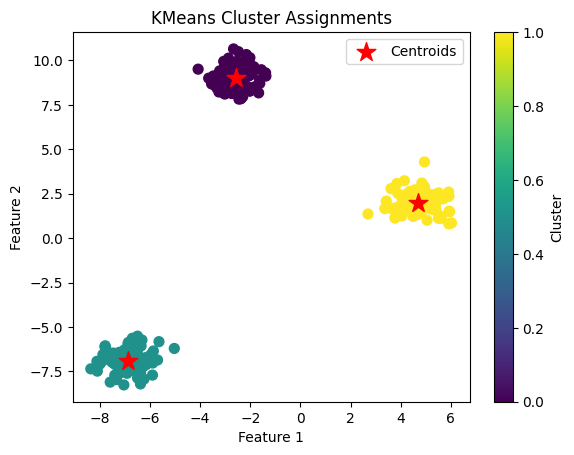

In [10]:
# Visualize the KMeans cluster assignments
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            s=200, c='red', marker='*', label='Centroids')
plt.title('KMeans Cluster Assignments')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.colorbar(label='Cluster')
plt.show()

Compared to the true labels:

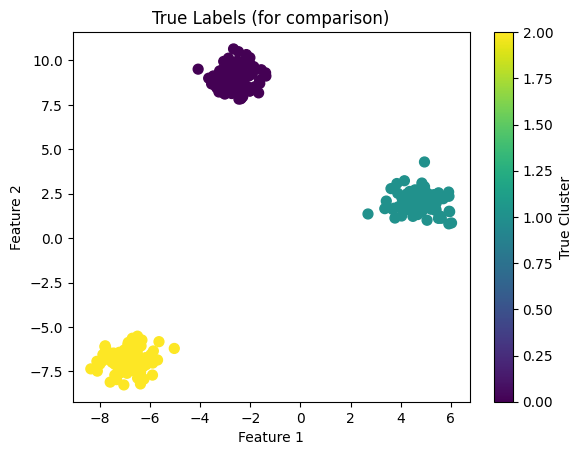

True labels (first 10): [2 2 0 1 2 1 0 1 0 0]


In [11]:
# Compare KMeans labels to true labels
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
plt.title('True Labels (for comparison)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='True Cluster')
plt.show()
print('True labels (first 10):', y[:10])

Here, we are probably satisfied with the clustering results. But in general we might want to have a more quantitative evaluation. How about comparing our cluster labels with the ground truth we got when generating the blobs?

In [12]:
from sklearn.metrics import accuracy_score

# This will likely give 0.0 because cluster IDs are arbitrary
print('Accuracy (raw labels):', accuracy_score(y, labels))

Accuracy (raw labels): 0.3333333333333333


In [13]:
# Print the true y array to understand label ordering
print('True y labels:', y[:20])
print('Predicted labels:', labels[:20])

True y labels: [2 2 0 1 2 1 0 1 0 0 0 1 0 0 2 0 2 1 0 0]
Predicted labels: [1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0]


---

**Exercise**

After looking at the "True" label array y, and the scatterplot and `labels` above, can you figure out why our computed accuracy is 0.0, not 1.0, and can you fix it?

---

Even though we recovered the partitioning of the data into clusters perfectly, the cluster IDs we assigned were arbitrary,
and we can not hope to recover them. Therefore, we must use a different scoring metric, such as ``adjusted_rand_score``, which is invariant to permutations of the labels:

In [14]:
from sklearn.metrics import adjusted_rand_score

# Use adjusted_rand_score which is invariant to label permutations
ars = adjusted_rand_score(y, labels)
print('Adjusted Rand Score:', ars)
print('(1.0 = perfect clustering, 0.0 = random clustering)')

Adjusted Rand Score: 1.0
(1.0 = perfect clustering, 0.0 = random clustering)


One of the "short-comings" of K-means is that we have to specify the number of clusters, which we often don't know *apriori*. For example, let's have a look what happens if we set the number of clusters to 2 in our synthetic 3-blob dataset:

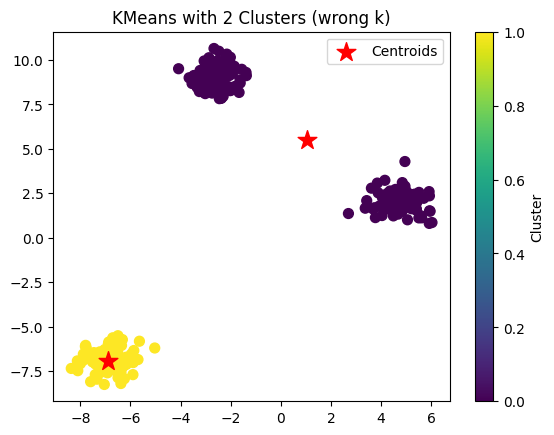

Adjusted Rand Score (k=2): 0.5697841726618705


In [15]:
# KMeans with wrong number of clusters (2 instead of 3)
km2 = KMeans(n_clusters=2, random_state=42)
y_pred2 = km2.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_pred2, s=50, cmap='viridis')
plt.scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1],
            s=200, c='red', marker='*', label='Centroids')
plt.title('KMeans with 2 Clusters (wrong k)')
plt.legend()
plt.colorbar(label='Cluster')
plt.show()
print('Adjusted Rand Score (k=2):', adjusted_rand_score(y, y_pred2))

#### The Elbow Method

The Elbow method is a "rule-of-thumb" approach to finding the optimal number of clusters. Here, we look at the cluster dispersion for different values of k:

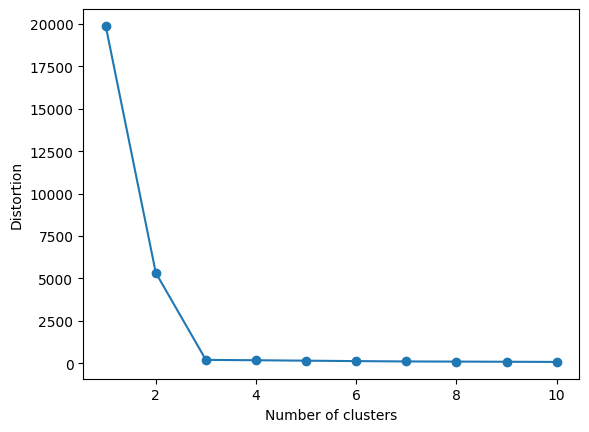

In [16]:
distortions = []
for i in range(1, 11):
    km = KMeans(n_clusters=i,
                random_state=0)
    km.fit(X)
    distortions.append(km.inertia_)
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')

plt.show()

Then, we pick the value that resembles the "pit of an elbow." As we can see, this would be k=3 in this case, which makes sense given our visual expection of the dataset previously.

**Clustering comes with assumptions**: A clustering algorithm finds clusters by making assumptions with samples should be grouped together. Each algorithm makes different assumptions and the quality and interpretability of your results will depend on whether the assumptions are satisfied for your goal. For K-means clustering, the model is that all clusters have equal, spherical variance.

**In general, there is no guarantee that structure found by a clustering algorithm has anything to do with what you were interested in**.


We can easily create a dataset that has non-isotropic clusters, on which kmeans will fail:

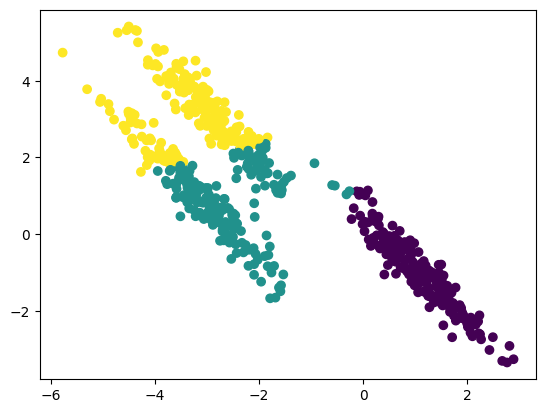

In [17]:
from sklearn.datasets import make_blobs

X, y = make_blobs(random_state=170, n_samples=600)
rng = np.random.RandomState(74)

transformation = rng.normal(size=(2, 2))
X = np.dot(X, transformation)

y_pred = KMeans(n_clusters=3).fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred)

## Some Notable Clustering Routines

The following are two well-known clustering algorithms.

- `sklearn.cluster.KMeans`: <br/>
    The simplest, yet effective clustering algorithm. Needs to be provided with the
    number of clusters in advance, and assumes that the data is normalized as input
    (but use a PCA model as preprocessor).
- `sklearn.cluster.MeanShift`: <br/>
    Can find better looking clusters than KMeans but is not scalable to high number of samples.
- `sklearn.cluster.DBSCAN`: <br/>
    Can detect irregularly shaped clusters based on density, i.e. sparse regions in
    the input space are likely to become inter-cluster boundaries. Can also detect
    outliers (samples that are not part of a cluster).
- `sklearn.cluster.AffinityPropagation`: <br/>
    Clustering algorithm based on message passing between data points.
- `sklearn.cluster.SpectralClustering`: <br/>
    KMeans applied to a projection of the normalized graph Laplacian: finds
    normalized graph cuts if the affinity matrix is interpreted as an adjacency matrix of a graph.
- `sklearn.cluster.Ward`: <br/>
    Ward implements hierarchical clustering based on the Ward algorithm,
    a variance-minimizing approach. At each step, it minimizes the sum of
    squared differences within all clusters (inertia criterion).

Of these, Ward, SpectralClustering, DBSCAN and Affinity propagation can also work with precomputed similarity matrices.

<img src="figures/cluster_comparison.png" width="900">

## Exercise: digits clustering

Perform K-means clustering on the digits data, searching for ten clusters.
Visualize the cluster centers as images (i.e. reshape each to 8x8 and use
``plt.imshow``)  Do the clusters seem to be correlated with particular digits? What is the ``adjusted_rand_score``?

Visualize the projected digits as in the last notebook, but this time use the
cluster labels as the color.  What do you notice?

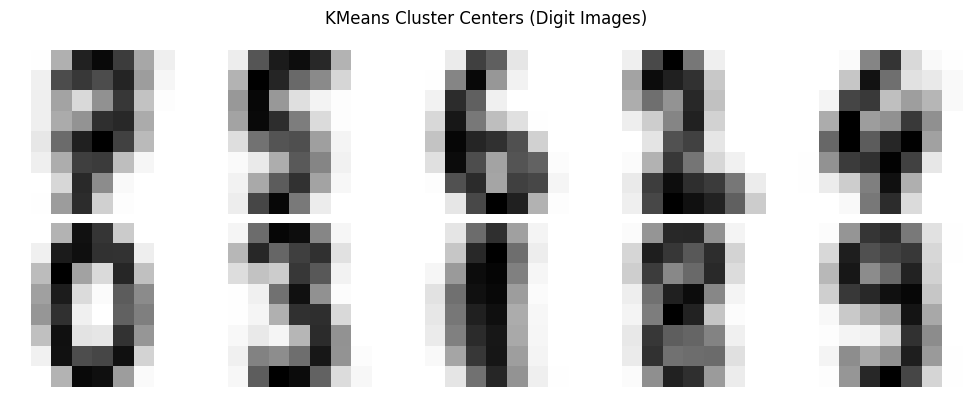

Adjusted Rand Score: 0.725814218974996


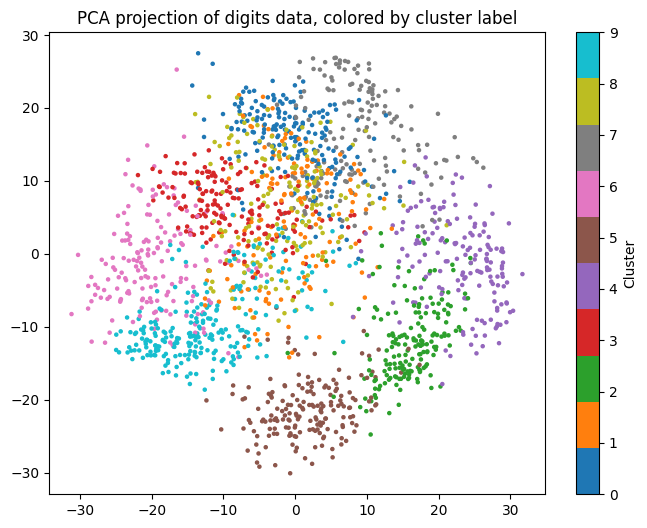

In [18]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()

# Perform KMeans clustering with 10 clusters (one per digit)
km_digits = KMeans(n_clusters=10, random_state=42)
km_digits.fit(digits.data)

# Visualize the cluster centers as 8x8 images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, center in zip(axes.ravel(), km_digits.cluster_centers_):
    ax.imshow(center.reshape(8, 8), cmap='binary', interpolation='nearest')
    ax.axis('off')
plt.suptitle('KMeans Cluster Centers (Digit Images)')
plt.tight_layout()
plt.show()

# Compute adjusted_rand_score
print('Adjusted Rand Score:', adjusted_rand_score(digits.target, km_digits.labels_))

# Visualize the digits projected via PCA, colored by cluster labels
pca = PCA(n_components=2)
X_pca = pca.fit_transform(digits.data)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_digits.labels_, cmap='tab10', s=5)
plt.title('PCA projection of digits data, colored by cluster label')
plt.colorbar(label='Cluster')
plt.show()

In [19]:
#%load solutions/08B_digits_clustering.py